# Hello World: Quantum Machine Learning with Merlin (Processor)

This notebook uses Merlin to build a quantum reservoir classifier for the Iris dataset. The reservoir is evaluated through `MerlinProcessor`: local Perceval SLOS is the default path, and a commented cloud simulator path is provided next to it.

Gradients are not propagated through processor execution, so the reservoir outputs are computed once and the training loop only updates the classical PyTorch head.

## 1. Install and Import Dependencies

First, let's make sure all required packages are installed and import them.  
If you haven't installed Merlin yet, run:  
`pip install merlinquantum` in your terminal or `!pip install merlinquantum` in your notebook.

In [22]:
import random

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import merlin as ML
import perceval as pcvl
from merlin import MerlinProcessor
from merlin.datasets import iris
from perceval import Processor
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

## 2. Define the Processor (Cloud `sim:slos` or Local SLOS)

Use the local SLOS processor by default. To run on Quandela Cloud, comment the local block and uncomment the `RemoteProcessor` block.

`sim:slos` is a noise-free cloud simulator. Use `sim:belenos` when you want a simulator that reproduces the noise of the `qpu:belenos` QPU. For Scaleway-hosted platforms and future session-based providers, use `pcvl.providers.scaleway` instead of `pcvl.RemoteProcessor`.

In [15]:
# Cloud simulator path. Use this block instead of the local SLOS block below.
# Save CLOUD_TOKEN in a .env file next to this notebook, or set it in your environment.
# from dotenv import load_dotenv
# import os
# load_dotenv()
# pcvl.RemoteConfig.set_token(os.getenv("CLOUD_TOKEN"))
# remote_processor = pcvl.RemoteProcessor("sim:slos")

# proc = MerlinProcessor(
#     processor=remote_processor,
#     microbatch_size=32,
#     timeout=3600.0,
#     max_shots_per_call=None,
#     chunk_concurrency=1,
# )

In [16]:
# Local SLOS path. This is the default path for running without cloud credentials.
local_processor = Processor("SLOS")
proc = MerlinProcessor(processor=local_processor)

## 3. Load and Prepare the Iris Dataset

We'll use the classic Iris dataset, a simple and well-known benchmark for classification.  
Let's load the data and convert it to PyTorch tensors for training.

In [17]:
train_features, train_labels, train_metadata = iris.get_data_train()
test_features, test_labels, test_metadata = iris.get_data_test()

X_train = torch.FloatTensor(train_features)
y_train = torch.LongTensor(train_labels)
X_test = torch.FloatTensor(test_features)
y_test = torch.LongTensor(test_labels)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")
print(f"Classes: {len(torch.unique(y_train))}")

Training samples: 120
Test samples: 30
Features: 4
Classes: 3


![iris](../_static/img/Iris_pipeline.png)

## 4. Define the Hybrid Model

The quantum reservoir is fixed. The processor evaluates it once on the train and test inputs, then the PyTorch model trains only the classical head on those reservoir outputs.

In [ ]:
# Define a simple sandwich reservoir layer
# The number of modes and photons is determined by the number of features in the dataset, and the output size is determined by the reservoir design. 
# The reservoir will be used to transform the input features into a higher-dimensional space before feeding them into a classical classifier head.
reservoir = ML.QuantumLayer.simple(input_size=X_train.shape[1]).eval()
output_size = reservoir.output_size
number_of_classes = len(torch.unique(y_train))
print(f"Reservoir output size: {output_size}")

# Process the training and test data through the reservoir to obtain the reservoir outputs. 
# These outputs will be used as features for training the classical classifier head.
train_reservoir_outputs = proc.forward(reservoir, X_train)
test_reservoir_outputs = proc.forward(reservoir, X_test)
print(f"Train reservoir outputs: {tuple(train_reservoir_outputs.shape)}")
print(f"Test reservoir outputs: {tuple(test_reservoir_outputs.shape)}")

# Simple MLP to process the reservoir outputs and perform classification.
class HybridIrisClassifier(nn.Module):
    """Classical head trained on processor-generated reservoir outputs."""

    def __init__(self, input_size: int, number_of_classes: int):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(input_size, 8),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(8, number_of_classes),
        )

    def forward(self, reservoir_outputs: torch.Tensor) -> torch.Tensor:
        return self.classifier(reservoir_outputs)

Reservoir output size: 10
Train reservoir outputs: (120, 10)
Test reservoir outputs: (30, 10)


## 5. Training Loop

The training loop uses the local processor outputs by default. Switching the processor cell to the cloud path changes only where the reservoir outputs are computed.

In [19]:
learning_rate = 0.01
number_of_epochs = 200


def reset_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def evaluate_accuracy(
    model: nn.Module, reservoir_outputs: torch.Tensor, labels: torch.Tensor
) -> float:
    model.eval()
    with torch.no_grad():
        predictions = model(reservoir_outputs).argmax(dim=1)
    return (predictions == labels).float().mean().item()


def train_classifier(seed: int, show_progress: bool = False) -> HybridIrisClassifier:
    reset_seeds(seed)
    model = HybridIrisClassifier(
        input_size=output_size,
        number_of_classes=number_of_classes,
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(number_of_epochs):
        optimizer.zero_grad()
        loss = criterion(model(train_reservoir_outputs), y_train)
        loss.backward()
        optimizer.step()

        if show_progress and (epoch + 1) % 20 == 0:
            accuracy = evaluate_accuracy(model, test_reservoir_outputs, y_test)
            model.train()
            print(
                f"Epoch {epoch + 1}: loss={loss.item():.4f}, "
                f"test accuracy={accuracy:.4f}"
            )

    return model


model = train_classifier(seed=123, show_progress=True)

Epoch 20: loss=1.0620, test accuracy=0.2000
Epoch 40: loss=0.9501, test accuracy=0.6333
Epoch 60: loss=0.7851, test accuracy=0.6333
Epoch 80: loss=0.6372, test accuracy=0.8667
Epoch 100: loss=0.4931, test accuracy=0.8667
Epoch 120: loss=0.3959, test accuracy=0.8667
Epoch 140: loss=0.3717, test accuracy=0.8333
Epoch 160: loss=0.3562, test accuracy=0.8667
Epoch 180: loss=0.2730, test accuracy=0.8667
Epoch 200: loss=0.2365, test accuracy=0.9000


## 6. Observe Results

Evaluate the trained model once, then repeat the classical training loop across several seeds to observe the variation from classical initialization and dropout.

In [20]:
test_accuracy = evaluate_accuracy(model, test_reservoir_outputs, y_test)
print(f"Test accuracy: {test_accuracy:.4f}")

number_of_runs = 10
accuracies = []

for run_index in range(number_of_runs):
    trained_model = train_classifier(seed=123 + run_index)
    accuracies.append(evaluate_accuracy(trained_model, test_reservoir_outputs, y_test))

accuracies_tensor = torch.tensor(accuracies)
average_accuracy = accuracies_tensor.mean().item()
std_accuracy = accuracies_tensor.std(unbiased=True).item()
print(f"Average accuracy over {number_of_runs} runs: {average_accuracy:.4f} +/- {std_accuracy:.4f}")

Test accuracy: 0.9000
Average accuracy over 10 runs: 0.8533 +/- 0.0233


The confusion matrix shows which classes the final trained model confuses on the test split.

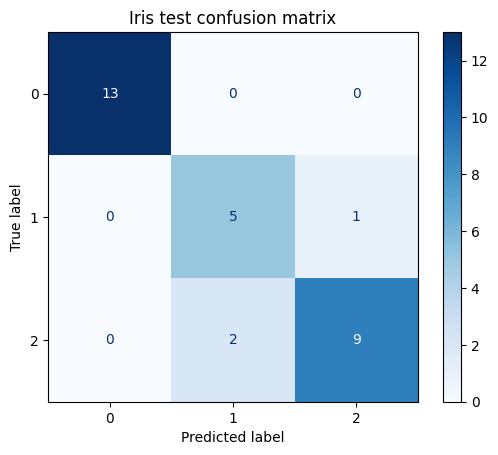

In [23]:
model.eval()
with torch.no_grad():
    test_predictions = model(test_reservoir_outputs).argmax(dim=1)

class_labels = [str(label) for label in range(number_of_classes)]
confusion = confusion_matrix(
    y_test.numpy(),
    test_predictions.numpy(),
    labels=list(range(number_of_classes)),
)

display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=class_labels,
)
display.plot(cmap="Blues", values_format="d")
plt.title("Iris test confusion matrix")
plt.show()

# Conclusion

This notebook defines a processor once, uses it to evaluate a fixed quantum reservoir, and trains only the classical classifier. To move from local SLOS to a cloud simulator or QPU-backed processor, change the processor definition in section 2 and keep the rest of the notebook unchanged.